# Customer Segmentation — Identifying Credit-Building Profiles

This notebook applies K-means clustering to `processed.csv` to discover natural groupings of borrowers based on their financial behavior. Rather than treating all borrowers as a monolith, segmentation lets us ask: **who are the distinct types of people in this dataset, and what does each group need?**

This is directly relevant to how a credit-building fintech like Kikoff thinks about its market — different segments have different risk profiles, different product needs, and different likelihoods of successfully building credit.

**Key questions explored:**
- How many meaningful borrower segments exist in this data?
- What financial behaviors define each segment?
- Which segment represents the best target for a credit-building product —
  high potential, currently underserved?

**Approach:**
- Feature selection and standardization for distance-based clustering
- Optimal k selection via elbow plot and silhouette scores
- K-means clustering and cluster profiling
- PCA visualization to assess cluster separation
- Segment naming and product framing

**Input:** `data/processed.csv` from `01_eda.ipynb`  
**Output:** `data/clustered.csv` with cluster labels for use in `03_modeling.ipynb`

## 1. Load processed.csv

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [24]:
df = pd.read_csv('data/processed.csv', index_col=0)

In [25]:
df.shape

(150000, 17)

In [26]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,MonthlyIncome_log,DebtRatio_log,EverLate30,EverLate60,EverLate90,DebtRatio_high
0,1.0,0.766127,45.0,2.0,0.802982,9120.0,13.0,0.0,6.0,0.0,2.000000e+00,9.118335,0.589442,1,0,0,0
1,0.0,0.957151,40.0,0.0,0.121876,2600.0,4.0,0.0,0.0,0.0,1.000000e+00,7.863651,0.115002,0,0,0,0
2,0.0,0.658180,38.0,1.0,0.085113,3042.0,2.0,1.0,0.0,0.0,1.110223e-16,8.020599,0.081684,1,0,1,0
3,0.0,0.233810,30.0,0.0,0.036050,3300.0,5.0,0.0,0.0,0.0,1.110223e-16,8.101981,0.035415,0,0,0,0
4,0.0,0.907239,49.0,1.0,0.024926,63588.0,7.0,0.0,1.0,0.0,1.110223e-16,11.060196,0.024620,1,0,0,0


## 2. Feature selection for clustering + scaling

| Feature | Description | Reason Included |
|---|---|---|
| `RevolvingUtilizationOfUnsecuredLines` | Credit card balance as % of total credit limit | Strongest single signal of credit stress |
| `MonthlyIncome_log` | Log-transformed monthly gross income | Financial capacity — affects ability to repay |
| `EverLate30` | Ever 30–59 days past due (binary) | Early delinquency signal |
| `EverLate60` | Ever 60–89 days past due (binary) | Escalating delinquency signal |
| `EverLate90` | Ever 90+ days past due (binary) | Severe delinquency signal |
| `DebtRatio_high` | Monthly debt obligations exceed monthly income (binary) | Financial stress flag |
| `age` | Borrower age in years | Credit maturity and life stage proxy |

**Features excluded:**
- Raw past-due count columns — replaced by binary `EverLate` flags; near-perfectly correlated with each other (0.98–0.99), adding no new information
- `MonthlyIncome` — superseded by `MonthlyIncome_log` which is less skewed
- `DebtRatio` — superseded by `DebtRatio_high`
- `NumberOfOpenCreditLinesAndLoans`, `NumberRealEstateLoansOrLines`, `NumberOfDependents` — describe who a borrower is rather than how they are managing their finances; weak behavioral signal for segmentation

Features will be standardized using `StandardScaler` prior to clustering — K-means is distance-based and sensitive to scale.Sonnet 4.6Adaptive

In [27]:
cluster_features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'MonthlyIncome_log',
    'EverLate30',
    'EverLate60',
    'EverLate90',
    'DebtRatio_high',
    'age'
]

In [28]:
X = df[cluster_features]

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [30]:
print(f"Clustering on {X_scaled.shape[1]} features across {X_scaled.shape[0]} borrowers")

Clustering on 7 features across 150000 borrowers


## 3. Find optimal k

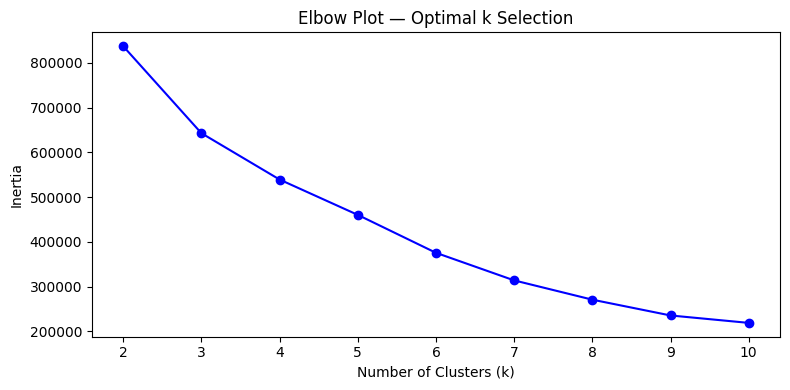

In [31]:
inertia = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Plot — Optimal k Selection')
plt.xticks(k_range)
plt.tight_layout()
plt.show()


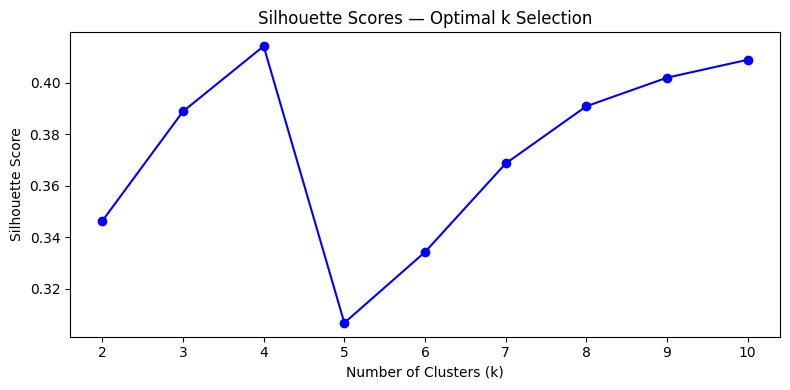

In [32]:
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(8, 4))
plt.plot(k_range, silhouette_scores, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores — Optimal k Selection')
plt.xticks(k_range)
plt.tight_layout()
plt.show()

## Optimal k Selection

### Elbow Plot
The elbow plot shows a gradual, continuous decline in inertia with no sharp kink — common with real-world financial data where borrower behavior exists on a spectrum rather than in perfectly distinct groups. The curve begins to flatten around k=3–4, suggesting diminishing returns beyond that point.

### Silhouette Score
The silhouette score peaks clearly at **k=4 (score ≈ 0.41)**, indicating this is where cluster cohesion and separation are jointly maximized. The sharp drop at k=5 confirms that splitting into 5 clusters introduces overlap and weakens the groupings.

Note: silhouette scores shifted from the initial run following a data quality fix in `01_eda.ipynb` — near-zero `MonthlyIncome` values (~12% of rows) were flagged and re-imputed, altering the underlying feature distributions and cluster structure.

### Decision: k=4
Both methods converge around k=4 — the elbow plot suggests the curve flattens there and the silhouette score peaks there. Four clusters is also practically interpretable: enough to capture meaningfully distinct borrower profiles without over-segmenting into groups too granular to act on from a product perspective.

## 4. Fit K-means

In [38]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

In [39]:
print(df['cluster'].value_counts().sort_index())

cluster
0    92693
1    30741
2     8324
3    18242
Name: count, dtype: int64


In [40]:
profile = df.groupby('cluster')[cluster_features].mean().round(3)
print(profile)

         RevolvingUtilizationOfUnsecuredLines  MonthlyIncome_log  EverLate30  \
cluster                                                                        
0                                       0.280              8.611       0.000   
1                                       0.248              4.667       0.046   
2                                       0.762              8.065       0.522   
3                                       0.480              8.542       0.999   

         EverLate60  EverLate90  DebtRatio_high     age  
cluster                                                  
0             0.020         0.0           0.000  52.271  
1             0.017         0.0           0.999  55.732  
2             0.336         1.0           0.216  45.957  
3             0.130         0.0           0.144  49.518  


## Data Quality Flag — MonthlyIncome

~12% of borrowers (17,869 rows) have a recorded `MonthlyIncome` below $1. These near-zero values (e.g. $0.20, $0.40) are almost certainly data entry errors rather than true income — they were not caught during initial imputation because they were recorded as valid numeric values rather than `NaN`.

**Resolution:** Returned to `01_eda.ipynb` to treat `MonthlyIncome < 1` as missing prior to KNN imputation. This increased the missing value count from ~20% to ~21% before re-imputation. `processed.csv` was regenerated and all downstream steps re-run from scratch.

## 5. Cluster profile + Segment naming

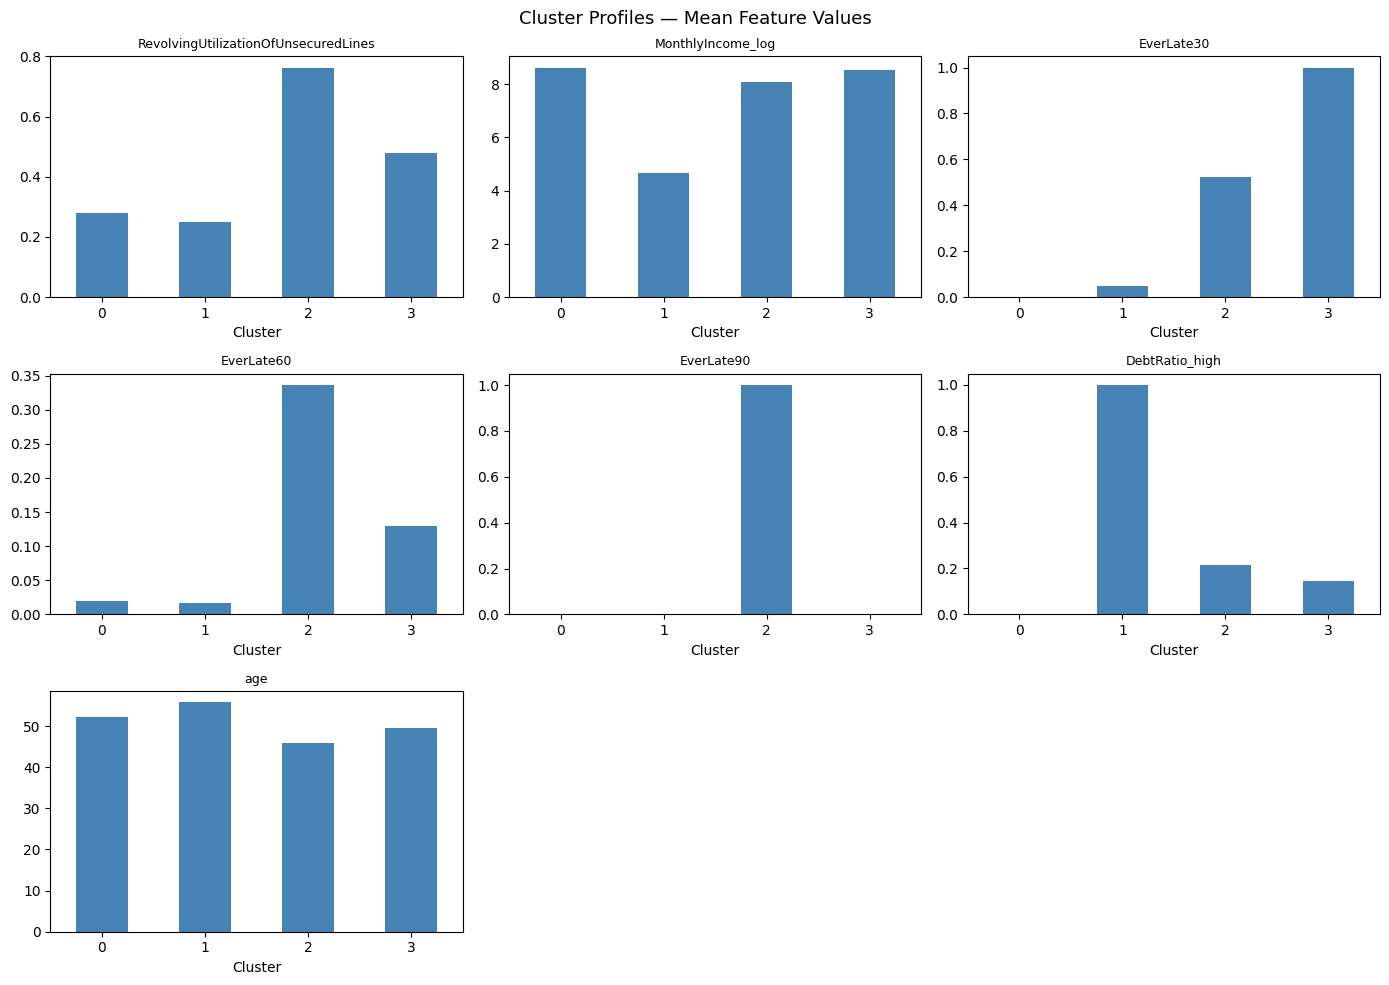

In [43]:
profile = df.groupby('cluster')[cluster_features].mean().round(3)

fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(cluster_features):
    profile[col].plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='none')
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('Cluster')
    axes[i].set_xticks(range(4))
    axes[i].set_xticklabels([0, 1, 2, 3], rotation=0)

for j in range(len(cluster_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Cluster Profiles — Mean Feature Values', fontsize=13)
plt.tight_layout()
plt.show()

In [44]:
cluster_names = {
    0: 'Established & Stable',
    1: 'Debt Burdened',
    2: 'Seriously Delinquent',
    3: 'Early Risk'
}

df['cluster_name'] = df['cluster'].map(cluster_names)
print(df['cluster_name'].value_counts())

cluster_name
Established & Stable    92693
Debt Burdened           30741
Early Risk              18242
Seriously Delinquent     8324
Name: count, dtype: int64



| Cluster | Name | Size | % |
|---|---|---|---|
| 0 | Established & Stable | 92,693 | 61.8% |
| 1 | Debt Burdened | 30,741 | 20.5% |
| 2 | Seriously Delinquent | 8,324 | 5.5% |
| 3 | Early Risk | 18,242 | 12.2% |


**Cluster 0 — Established & Stable**
Low revolving utilization (0.28), highest income (log ~8.6), near-zero delinquency history across all three time windows, and zero debt stress. These borrowers are financially healthy and well-established — unlikely to need credit-building products but represent a useful baseline for comparison. Second oldest segment (~52).

**Cluster 1 — Debt Burdened**
Low utilization and minimal delinquency history, but **100% carry debt obligations exceeding their monthly income** (DebtRatio_high = 1.0). Income is the lowest of any group (log ~4.7 ≈ ~$110/month after re-imputation), suggesting these borrowers are structurally constrained rather than behaviorally risky. Oldest segment (~56).

**Cluster 2 — Seriously Delinquent**
Highest revolving utilization (0.76), **100% have been 90+ days late**, and one third have been 60 days late. Moderate debt stress. The youngest segment (~46), suggesting early-career financial instability. Highest risk group in the dataset — least likely to benefit from a credit-building product without financial coaching.

**Cluster 3 — Early Risk**
Moderate utilization (0.48), good income (log ~8.5), **~100% have been 30 days late** but virtually no 60 or 90-day delinquency. Low debt stress. These borrowers have shown early signs of financial stress but have not yet escalated — the most promising segment for a credit-building intervention.

## 6. Visualization

In [45]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]


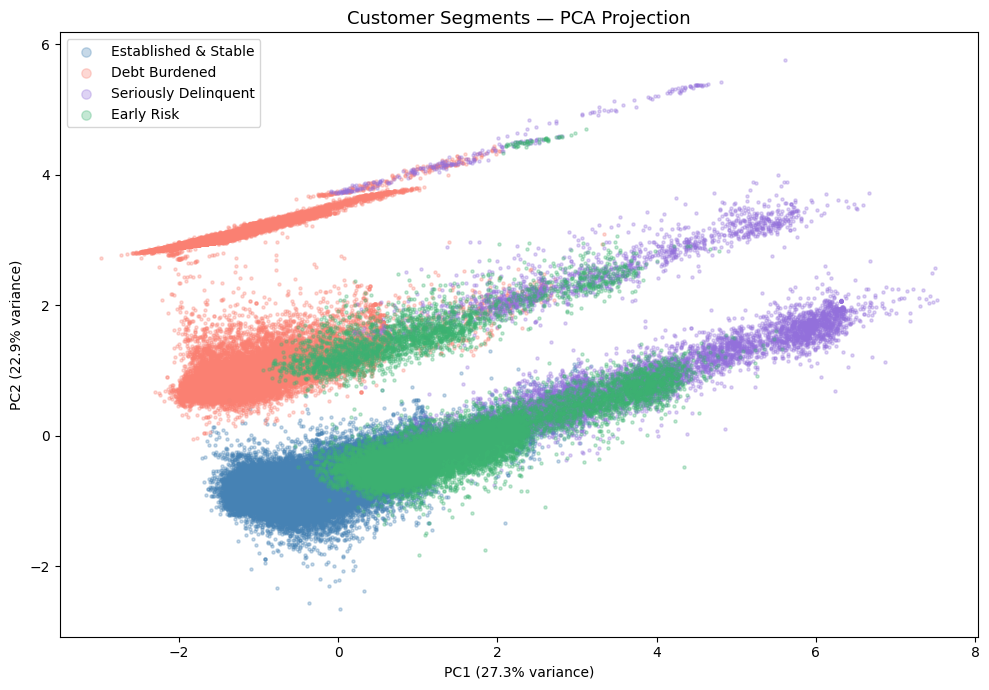

Total variance explained: 50.2%


In [46]:
colors = {0: 'steelblue', 1: 'salmon', 2: 'mediumpurple', 3: 'mediumseagreen'}

plt.figure(figsize=(10, 7))
for cluster, name in cluster_names.items():
    mask = df['cluster'] == cluster
    plt.scatter(
        df.loc[mask, 'pca1'],
        df.loc[mask, 'pca2'],
        c=colors[cluster],
        label=name,
        alpha=0.3,
        s=5
    )

plt.title('Customer Segments — PCA Projection', fontsize=13)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

print(f"Total variance explained: {pca.explained_variance_ratio_.sum()*100:.1f}%")

## Cluster Visualization

### PCA Projection
**Interpretation**
Clusters show partial separation in 2D space, with Debt Burdened (orange) and Established & Stable (blue) most visually distinct. However, significant overlap exists between Early Risk and Seriously Delinquent — expected given they share some behavioral similarities (elevated utilization, delinquency history).

**Limitation**
The diagonal stripe pattern is an artifact of the binary features (`EverLate30`, `EverLate60`, `EverLate90`, `DebtRatio_high`) — 0/1 values create discrete bands rather than smooth blobs in PCA space. More importantly, 50.2% variance explained means ~50% of the cluster separation information is lost in this 2D projection. The clusters are more meaningfully separated in the original 7-dimensional feature space, as confirmed by the silhouette score of 0.41 at k=4.

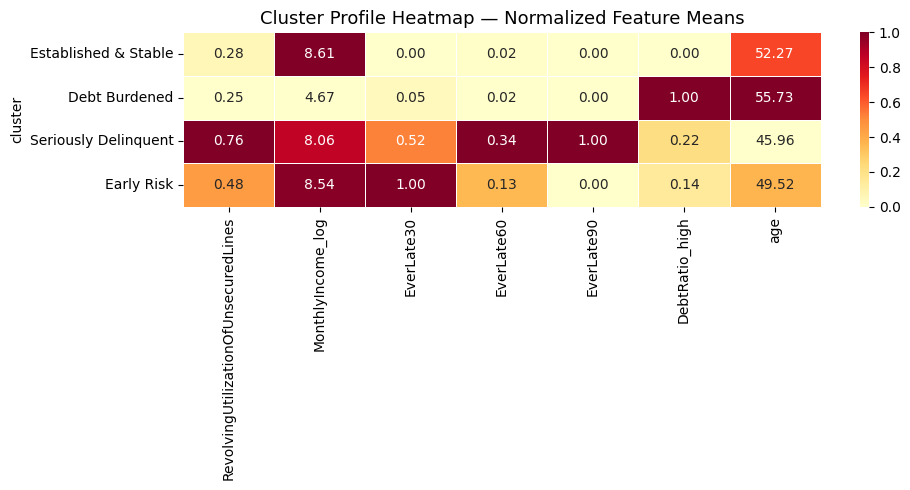

In [50]:
profile_norm = profile.copy()
scaler_mm = MinMaxScaler()
profile_norm = pd.DataFrame(
    scaler_mm.fit_transform(profile),
    columns=profile.columns,
    index=profile.index
)

plt.figure(figsize=(10, 5))
sns.heatmap(
    profile_norm,
    annot=profile.values,
    fmt='.2f',
    cmap='YlOrRd',
    linewidths=0.5,
    yticklabels=[cluster_names[i] for i in range(4)]
)
plt.title('Cluster Profile Heatmap — Normalized Feature Means', fontsize=13)
plt.tight_layout()
plt.show()

### Cluster Profile Heatmap

**Key patterns:**
- **Established & Stable** — uniformly light across all risk features; the clean baseline
- **Debt Burdened** — almost entirely clean except `DebtRatio_high = 1.00`; risk is structural (income vs obligations) not behavioral
- **Seriously Delinquent** — dark on utilization, `EverLate30`, `EverLate60`, and `EverLate90`; the highest-risk segment across every delinquency dimension
- **Early Risk** — `EverLate30 = 1.00` stands out against clean 60/90-day history; these borrowers have shown early stress signals but have not escalated

## 7. Map to product

In [53]:
product_map = {
    'Established & Stable': 'Not a primary target — already credit healthy',
    'Debt Burdened': 'Financial coaching and/or budgeting tools before credit products',
    'Seriously Delinquent': 'Debt counseling — not ready for credit building',
    'Early Risk': 'PRIMARY TARGET — credit builder line + financial education'
}

In [55]:
df['product_recommendation'] = df['cluster_name'].map(product_map)
print(df['product_recommendation'].value_counts(normalize=True).round(3))

product_recommendation
Not a primary target — already credit healthy                       0.618
Financial coaching and/or budgeting tools before credit products    0.205
PRIMARY TARGET — credit builder line + financial education          0.122
Debt counseling — not ready for credit building                     0.055
Name: proportion, dtype: float64


Each segment implies a different intervention:

| Segment | Size | Product Recommendation |
|---|---|---|
| Established & Stable | 92,693 (61.8%) | Not a primary target — already credit healthy |
| Debt Burdened | 30,741 (20.5%) | Financial coaching / budgeting tools before credit products |
| Seriously Delinquent | 8,324 (5.5%) | Debt counseling — not ready for credit building |
| Early Risk | 18,242 (12.2%) | **PRIMARY TARGET** — credit builder line + financial education |

### Rationale

**Early Risk is the primary target** for a credit-building product. These borrowers have good income and no severe delinquency history — their 30-day late payments signal early financial stress rather than entrenched default behavior. A structured credit-building product with low limits and financial education could help them course-correct before stress escalates to 60 or 90-day delinquency.

**Debt Burdened borrowers** have a structural problem — obligations exceeding income — that a credit product alone cannot solve. Offering credit here risks adding to their burden. Financial coaching or income-based budgeting tools are a better first step, with credit products as a second phase once obligations are under control.

**Seriously Delinquent borrowers** are the highest risk and least likely to benefit from credit building in the short term. 100% have been 90+ days late — introducing new credit lines without addressing underlying debt behavior is likely to worsen their situation.

**Established & Stable borrowers** are financially healthy and represent a useful analytical baseline, but are not the target market for a credit-building product.

## 8. Export clustered data

In [57]:
df.to_csv('data/clustered.csv', index=False)